In [ ]:
!pip install -q kagglehub
import kagglehub

In [ ]:
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Dataset downloaded to: /kaggle/input/network-intrusion-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [ ]:
data_path = "/root/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1"
files = os.listdir(data_path)
print("Available files:")
for file in files:
    print(f"  - {file}")

Available files:
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv


In [ ]:
dataframes = {}
for file in files:
    file_path = os.path.join(data_path, file)
    df_name = file.replace('.pcap_ISCX.csv', '').replace('-', '_')
    dataframes[df_name] = pd.read_csv(file_path)
    print(f"Loaded {df_name}: {dataframes[df_name].shape}")

Loaded Monday_WorkingHours: (529918, 79)
Loaded Thursday_WorkingHours_Afternoon_Infilteration: (288602, 79)
Loaded Friday_WorkingHours_Afternoon_DDos: (225745, 79)
Loaded Thursday_WorkingHours_Morning_WebAttacks: (170366, 79)
Loaded Wednesday_workingHours: (692703, 79)
Loaded Friday_WorkingHours_Afternoon_PortScan: (286467, 79)
Loaded Friday_WorkingHours_Morning: (191033, 79)
Loaded Tuesday_WorkingHours: (445909, 79)


In [ ]:
df = pd.concat(dataframes.values(), ignore_index=True)
print(f"Combined dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

Combined dataset shape: (2830743, 79)
Total rows: 2,830,743
Total columns: 79


In [ ]:
print("First 5 rows:")
print(df.head())
print("\n" + "="*100 + "\n")
print("Column names:")
print(df.columns.tolist())

First 5 rows:
    Destination Port   Flow Duration   Total Fwd Packets  \
0              49188               4                   2   
1              49188               1                   2   
2              49188               1                   2   
3              49188               1                   2   
4              49486               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        0                           12   
2                        0                           12   
3                        0                           12   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             0                       6   
2                             0                       6   
3                             0   

In [ ]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IA

In [ ]:
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("\nBasic statistics:")
print(df.describe())

Missing values per column:
Flow Bytes/s    1358
dtype: int64

Total missing values: 1358

Basic statistics:
        Destination Port   Flow Duration   Total Fwd Packets  \
count       2.830743e+06    2.830743e+06        2.830743e+06   
mean        8.071483e+03    1.478566e+07        9.361160e+00   
std         1.828363e+04    3.365374e+07        7.496728e+02   
min         0.000000e+00   -1.300000e+01        1.000000e+00   
25%         5.300000e+01    1.550000e+02        2.000000e+00   
50%         8.000000e+01    3.131600e+04        2.000000e+00   
75%         4.430000e+02    3.204828e+06        5.000000e+00   
max         6.553500e+04    1.200000e+08        2.197590e+05   

        Total Backward Packets  Total Length of Fwd Packets  \
count             2.830743e+06                 2.830743e+06   
mean              1.039377e+01                 5.493024e+02   
std               9.973883e+02                 9.993589e+03   
min               0.000000e+00                 0.000000e+00   


In [ ]:
print("Target Label Distribution:")
label_counts = df[' Label'].value_counts()
print(label_counts)
print("\nPercentage distribution:")
print((label_counts / len(df) * 100).round(2))

Target Label Distribution:
 Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Percentage distribution:
 Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS                           4.52
DoS GoldenEye                  0.36
FTP-Patator                    0.28
SSH-Patator                    0.21
DoS slowloris                  0.20
DoS Slowhttptest               0.19
Bot          

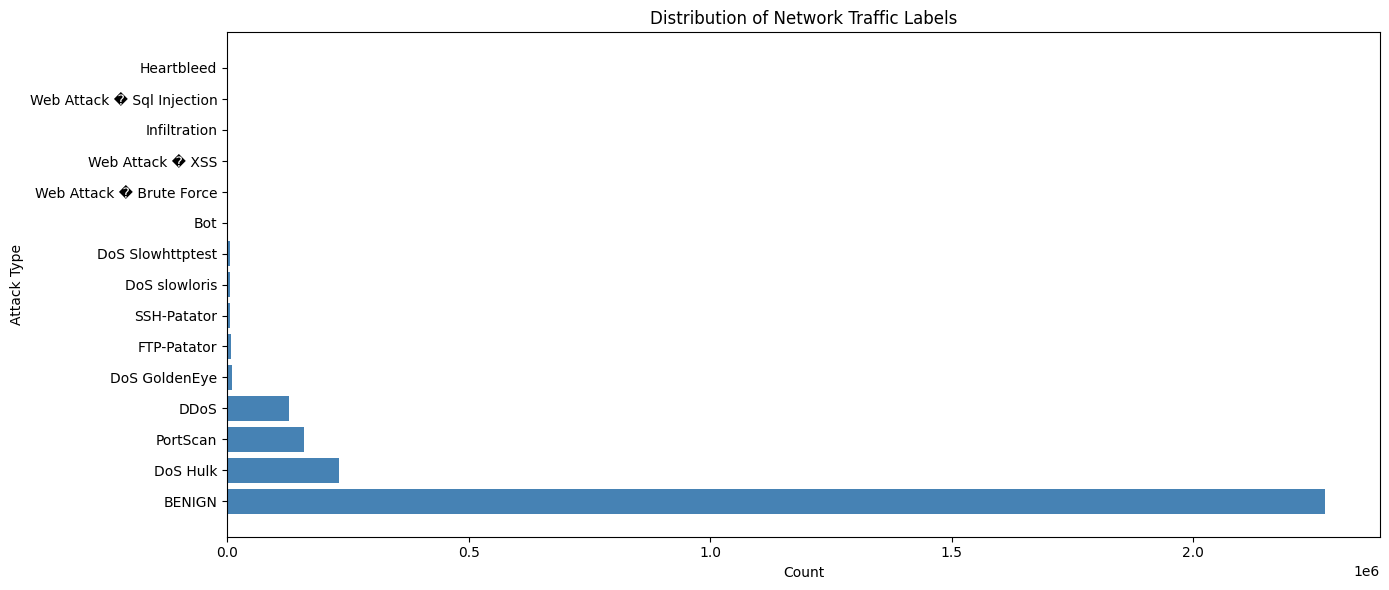

In [ ]:
plt.figure(figsize=(14, 6))
label_counts = df[' Label'].value_counts()
plt.barh(label_counts.index, label_counts.values, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Attack Type')
plt.title('Distribution of Network Traffic Labels')
plt.tight_layout()
plt.show()

In [ ]:
print("Data type distribution:")
print(df.dtypes.value_counts())
print("\nMemory usage by column (Top 10):")
memory_usage = df.memory_usage(deep=True).sort_values(ascending=False)
print(memory_usage.head(10))
print(f"\nTotal memory: {memory_usage.sum() / 1024**3:.2f} GB")

Data type distribution:
int64      54
float64    24
object      1
Name: count, dtype: int64

Memory usage by column (Top 10):
 Label                          156564239
 Destination Port                22645944
 Total Fwd Packets               22645944
 Flow Duration                   22645944
 Total Length of Bwd Packets     22645944
Total Length of Fwd Packets      22645944
 Fwd Packet Length Max           22645944
 Total Backward Packets          22645944
 Bwd Packet Length Min           22645944
 Fwd Packet Length Mean          22645944
dtype: int64

Total memory: 1.79 GB


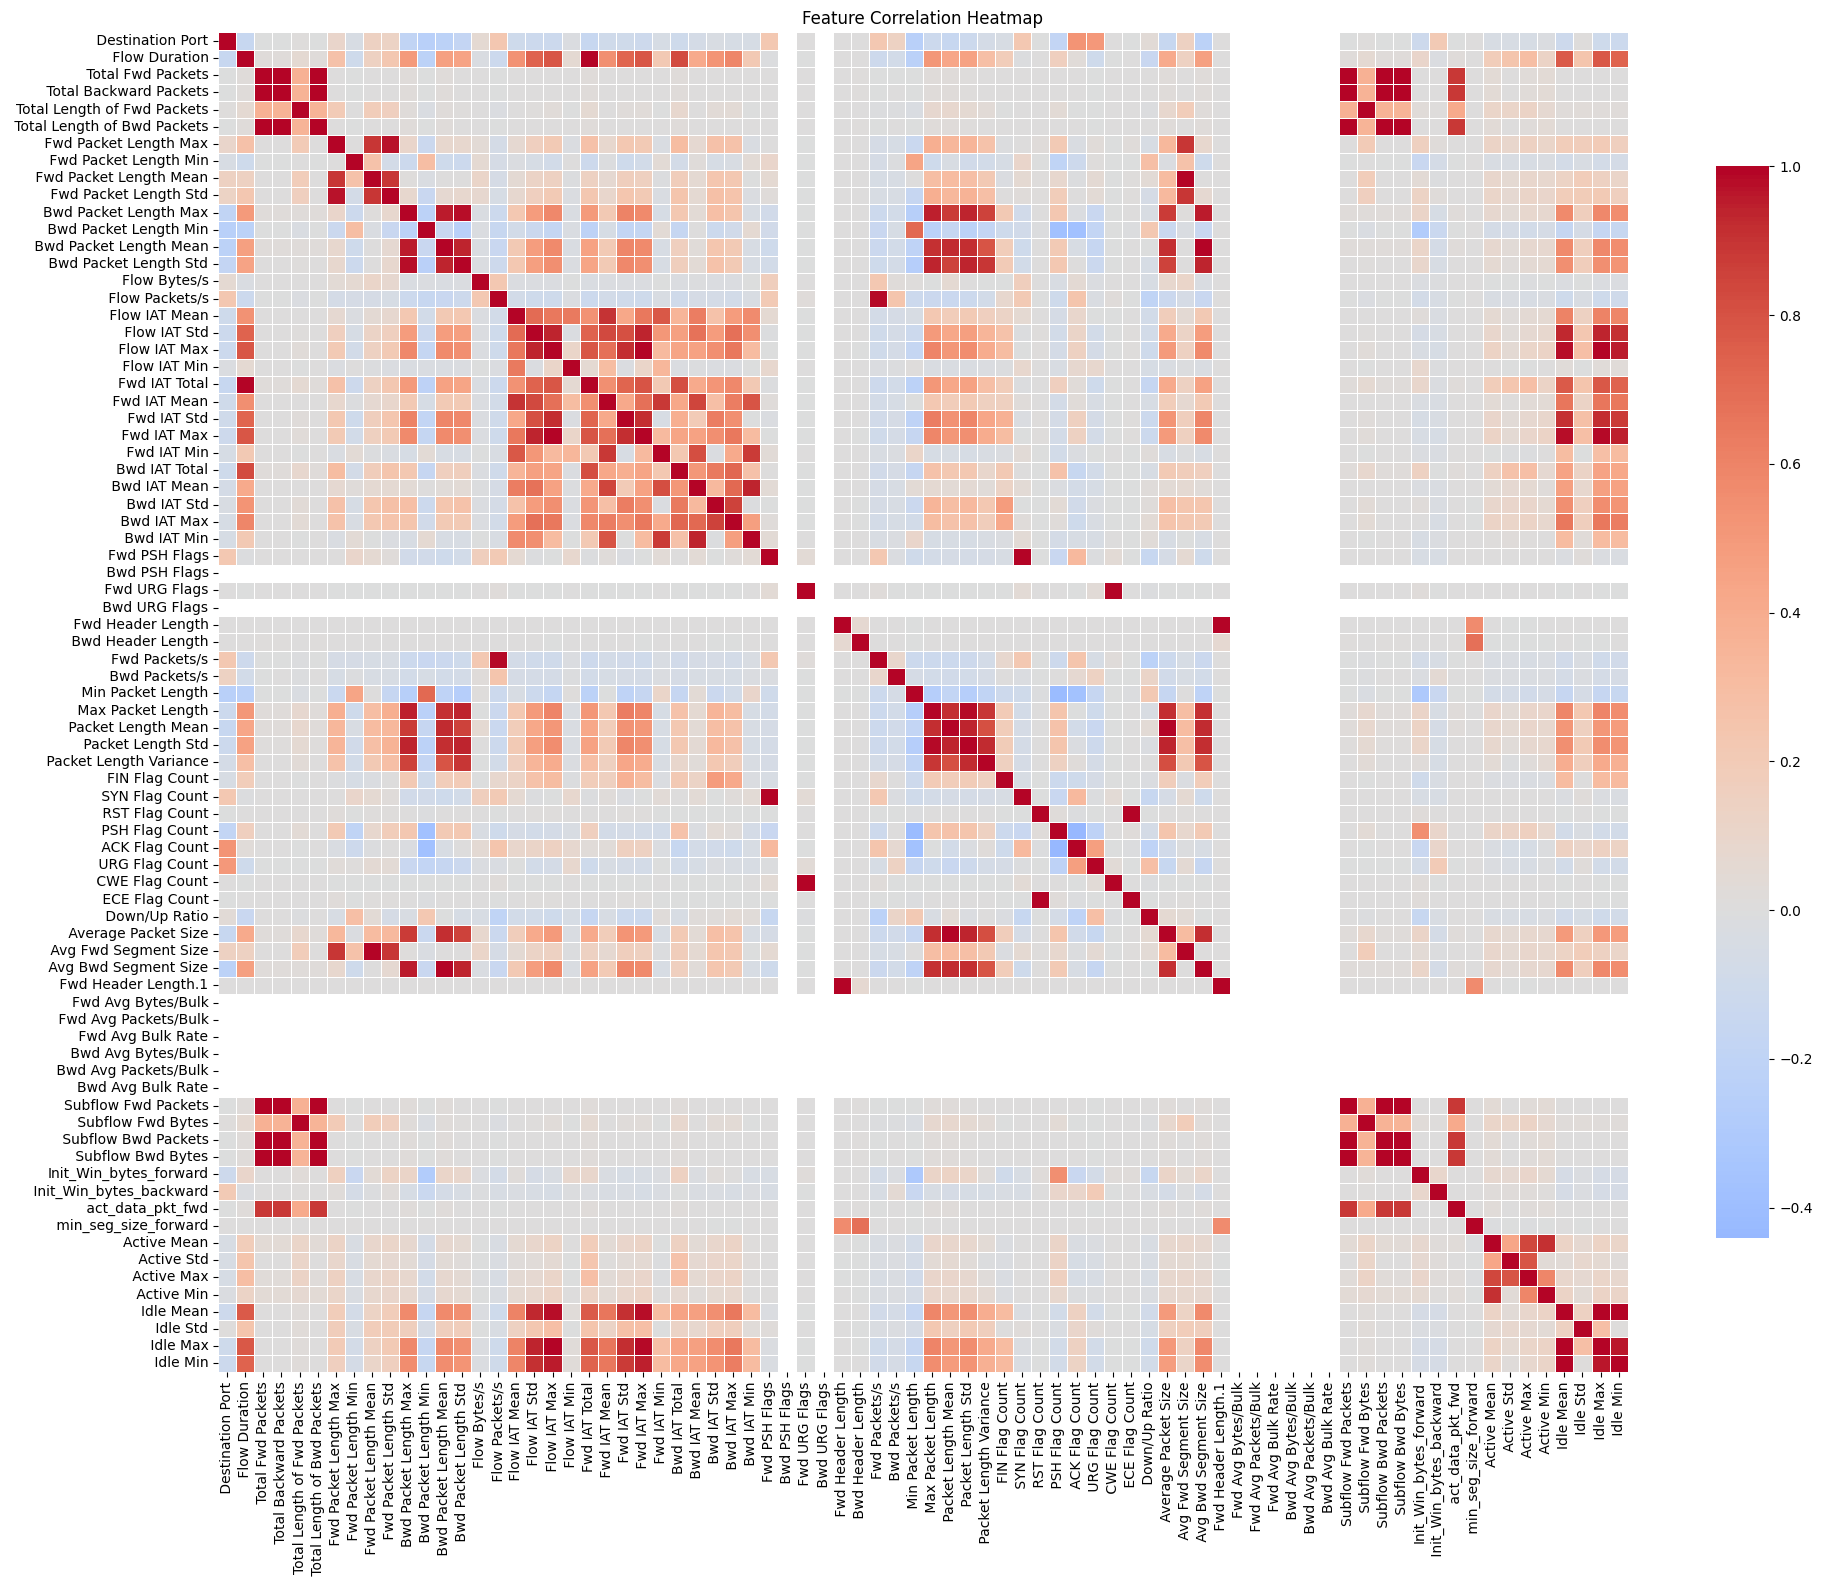

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
corr_threshold = 0.95
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > corr_threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Feature pairs with correlation > {corr_threshold}:")
for pair in high_corr_pairs[:20]:
    print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")
print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")

Feature pairs with correlation > 0.95:
 Flow Duration <-> Fwd IAT Total: 0.999
 Total Fwd Packets <->  Total Backward Packets: 0.999
 Total Fwd Packets <->  Total Length of Bwd Packets: 0.997
 Total Fwd Packets <-> Subflow Fwd Packets: 1.000
 Total Fwd Packets <->  Subflow Bwd Packets: 0.999
 Total Fwd Packets <->  Subflow Bwd Bytes: 0.997
 Total Backward Packets <->  Total Length of Bwd Packets: 0.994
 Total Backward Packets <-> Subflow Fwd Packets: 0.999
 Total Backward Packets <->  Subflow Bwd Packets: 1.000
 Total Backward Packets <->  Subflow Bwd Bytes: 0.994
Total Length of Fwd Packets <->  Subflow Fwd Bytes: 1.000
 Total Length of Bwd Packets <-> Subflow Fwd Packets: 0.997
 Total Length of Bwd Packets <->  Subflow Bwd Packets: 0.994
 Total Length of Bwd Packets <->  Subflow Bwd Bytes: 1.000
 Fwd Packet Length Max <->  Fwd Packet Length Std: 0.968
 Fwd Packet Length Mean <->  Avg Fwd Segment Size: 1.000
Bwd Packet Length Max <->  Bwd Packet Length Mean: 0.959
Bwd Packet Length Ma

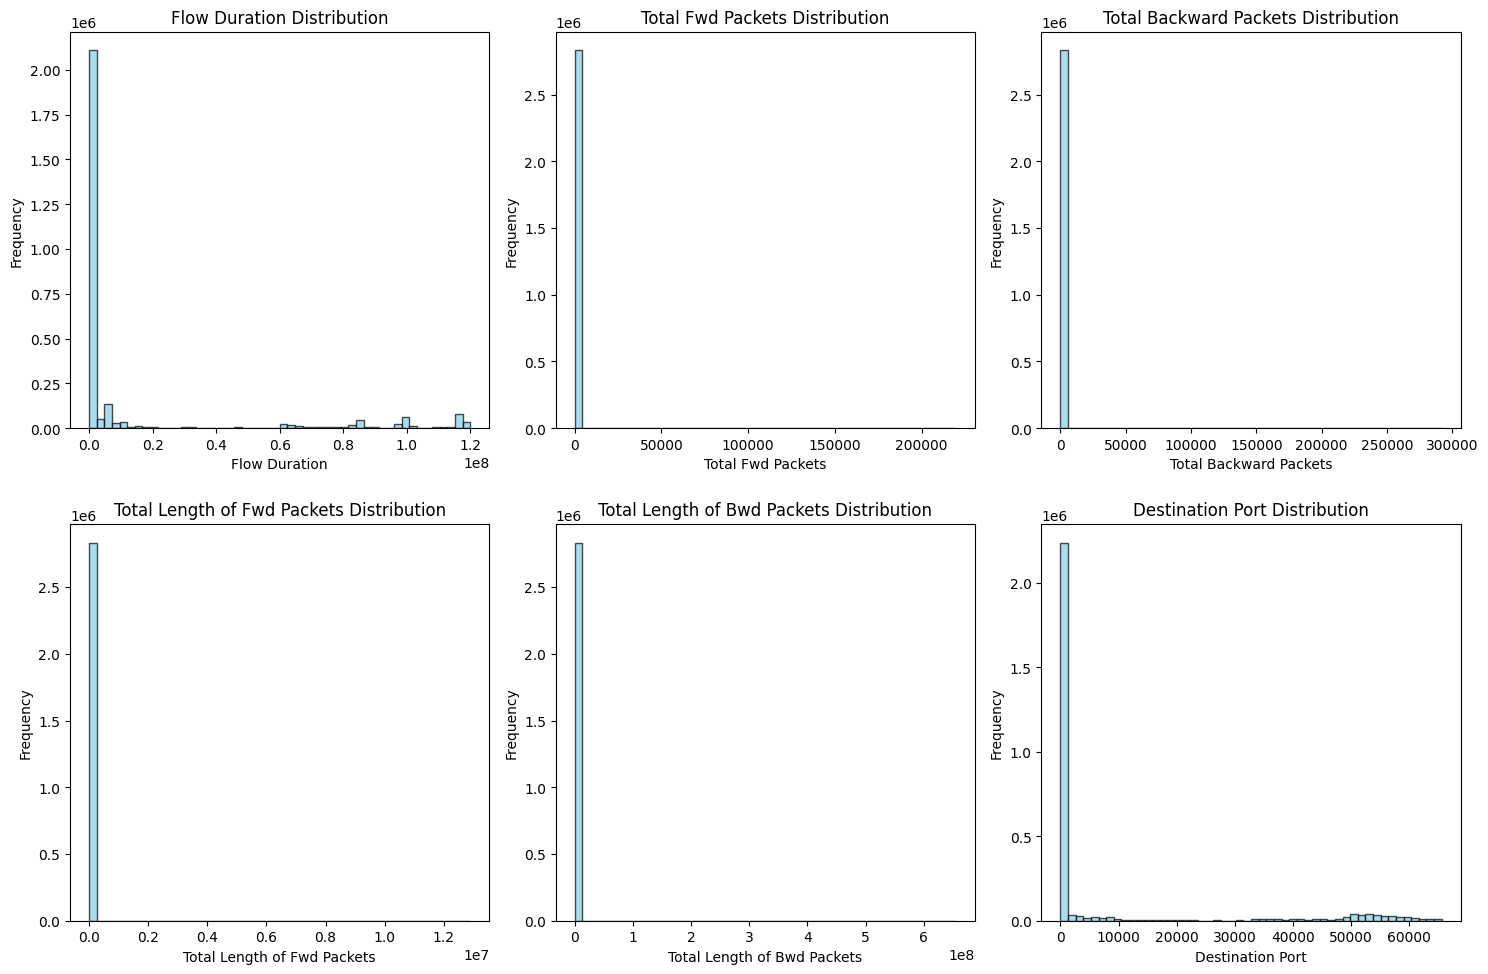

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = [' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets',
            'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Destination Port']
for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    axes[row, col].hist(df[feature], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'{feature.strip()} Distribution')
    axes[row, col].set_xlabel(feature.strip())
    axes[row, col].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
print("Infinite values per column:")
inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
print(inf_counts[inf_counts > 0])
print(f"\nTotal infinite values: {inf_counts.sum()}")

print("\n" + "="*60)
print("\nZero values percentage for key features:")
zero_counts = (df[numeric_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(2)
print(zero_pct[zero_pct > 50].sort_values(ascending=False).head(15))

Infinite values per column:
Flow Bytes/s       1509
 Flow Packets/s    2867
dtype: int64

Total infinite values: 4376


Zero values percentage for key features:
 Bwd PSH Flags           100.00
 Bwd URG Flags           100.00
 Bwd Avg Packets/Bulk    100.00
 Fwd Avg Bulk Rate       100.00
 Bwd Avg Bytes/Bulk      100.00
Fwd Avg Bytes/Bulk       100.00
 Fwd Avg Packets/Bulk    100.00
Bwd Avg Bulk Rate        100.00
 CWE Flag Count           99.99
 Fwd URG Flags            99.99
 ECE Flag Count           99.98
 RST Flag Count           99.98
FIN Flag Count            96.46
Fwd PSH Flags             95.36
 SYN Flag Count           95.36
dtype: float64


In [ ]:
df['is_attack'] = df[' Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)
print("Attack vs Benign comparison:")
comparison = df.groupby('is_attack')[numeric_cols].mean()
print(comparison[[' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', ' Destination Port']].T)
print("\n" + "="*60)
print("\nAttack types count:")
print(f"Benign: {(df['is_attack'] == 0).sum():,}")
print(f"Attack: {(df['is_attack'] == 1).sum():,}")

Attack vs Benign comparison:
is_attack                          0             1
Flow Duration           1.122082e+07  2.931681e+07
Total Fwd Packets       1.065417e+01  4.090532e+00
Total Backward Packets  1.213864e+01  3.281282e+00
Destination Port        9.419545e+03  2.576460e+03


Attack types count:
Benign: 2,273,097
Attack: 557,646


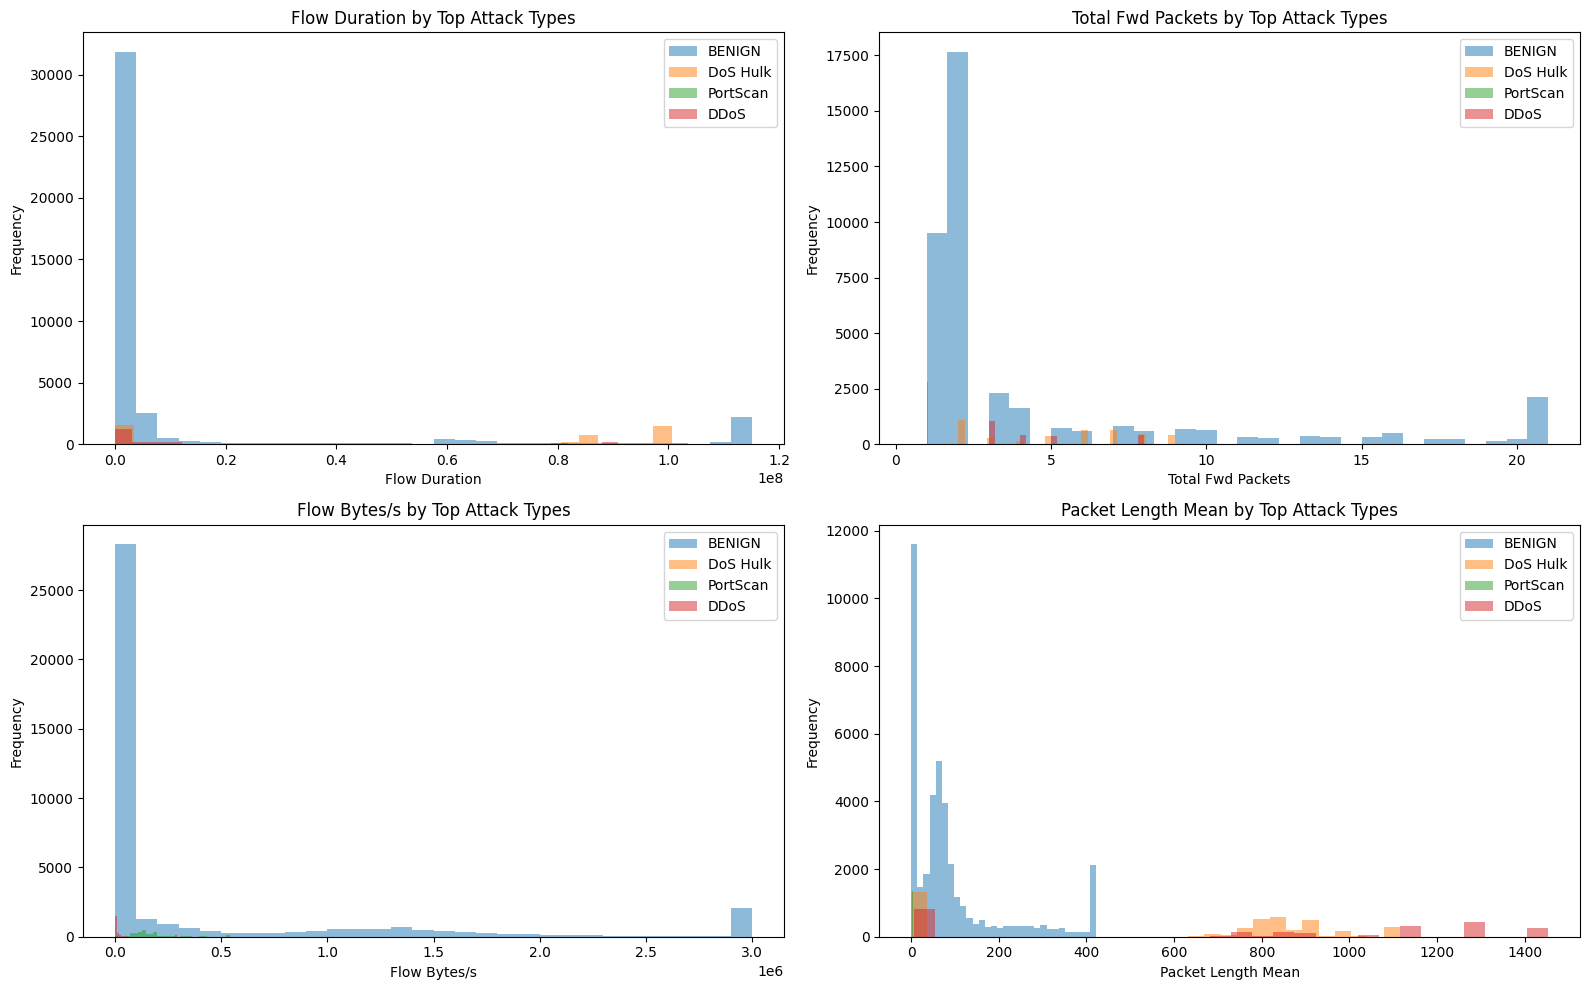

In [ ]:
plt.figure(figsize=(16, 10))
features_to_plot = [' Flow Duration', ' Total Fwd Packets', 'Flow Bytes/s', ' Packet Length Mean']
for idx, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, idx)
    df_sample = df.sample(n=50000, random_state=42)
    for label in ['BENIGN', 'DoS Hulk', 'PortScan', 'DDoS']:
        subset = df_sample[df_sample[' Label'] == label]
        if len(subset) > 0:
            plt.hist(subset[feature].clip(lower=0, upper=np.percentile(subset[feature].dropna(), 95)),
                     bins=30, alpha=0.5, label=label)
    plt.xlabel(feature.strip())
    plt.ylabel('Frequency')
    plt.title(f'{feature.strip()} by Top Attack Types')
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("Handling missing and infinite values...")
df_clean = df.copy()
df_clean = df_clean.fillna(0)
df_clean = df_clean.replace([np.inf, -np.inf], 0)
print(f"Missing values after handling: {df_clean.isnull().sum().sum()}")
print(f"Infinite values after handling: {np.isinf(df_clean.select_dtypes(include=[np.number])).sum().sum()}")
print(f"\nCleaned dataset shape: {df_clean.shape}")

Handling missing and infinite values...
Missing values after handling: 0
Infinite values after handling: 0

Cleaned dataset shape: (2830743, 80)


In [ ]:
print("Identifying constant and zero-variance features...")
zero_var_features = []
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].nunique() <= 1:
        zero_var_features.append(col)

print(f"Features with zero variance: {len(zero_var_features)}")
print(zero_var_features)

df_clean = df_clean.drop(columns=zero_var_features)
print(f"\nDataset shape after removing zero-variance features: {df_clean.shape}")

Identifying constant and zero-variance features...
Features with zero variance: 8
[' Bwd PSH Flags', ' Bwd URG Flags', 'Fwd Avg Bytes/Bulk', ' Fwd Avg Packets/Bulk', ' Fwd Avg Bulk Rate', ' Bwd Avg Bytes/Bulk', ' Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Dataset shape after removing zero-variance features: (2830743, 72)
